# AI, ML Assignment - Multi-Output Time-Series Forecasting using LSTM/GRU
## Name: Romana Ruqia
### M.Sc. AI & ML, Semester 2 (Department of Computer Science, Faculty of Sciences, Jamia Millia Islamia)
### Dataset used: 'Nestle India'

Import Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Load Dataset

In [93]:
df = pd.read_csv("NESTLEIND.csv")

In [94]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2010-01-08,NESTLEIND,EQ,2512.95,2555.00,2575.0,2475.20,2476.0,2494.65,2529.81,648,1.639316e+11,NaN,438,0.6759
1,2010-01-11,NESTLEIND,EQ,2494.65,2401.00,2515.0,2400.00,2500.0,2498.95,2494.44,825,2.057909e+11,NaN,638,0.7733
2,2010-01-12,NESTLEIND,EQ,2498.95,2540.00,2540.0,2471.35,2505.0,2502.85,2485.22,68346,1.698549e+13,NaN,67695,0.9905
3,2010-01-13,NESTLEIND,EQ,2502.85,2502.85,2540.0,2480.00,2489.8,2489.35,2491.94,1032,2.571682e+11,NaN,718,0.6957
4,2010-01-14,NESTLEIND,EQ,2489.35,2535.00,2595.0,2470.00,2560.0,2568.20,2510.27,330361,8.292956e+13,NaN,329193,0.9965


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                2806 non-null   object 
 1   Symbol              2806 non-null   object 
 2   Series              2806 non-null   object 
 3   Prev Close          2806 non-null   float64
 4   Open                2806 non-null   float64
 5   High                2806 non-null   float64
 6   Low                 2806 non-null   float64
 7   Last                2806 non-null   float64
 8   Close               2806 non-null   float64
 9   VWAP                2806 non-null   float64
 10  Volume              2806 non-null   int64  
 11  Turnover            2806 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  2806 non-null   int64  
 14  %Deliverble         2806 non-null   float64
dtypes: float64(10), int64(2), object(3)
memory usage: 329.0

In [96]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

features = ['Prev Close','Open','High','Low','Last','Close','VWAP','Volume','Turnover','Deliverable Volume','%Deliverble']

data = df[features].ffill()

Normalize

In [57]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

Create Overlapping Sequences

In [72]:
def create_sequences(data, input_steps=5, output_steps=5, overlap=4):
    X, Y = [], []
    
    stride = input_steps - overlap
    
    for i in range(0, len(data) - input_steps - output_steps, stride):
        X.append(data[i:i+input_steps])
        Y.append(data[i+input_steps:i+input_steps+output_steps])
    
    return np.array(X), np.array(Y)

X, Y = create_sequences(scaled_data, 5, 5, overlap=4)

In [73]:
# 🔹 10 → 5 sequence creation

X_10, Y_10 = create_sequences(scaled_data, input_steps=10, output_steps=5, overlap=8)

print("10→5 Input shape:", X_10.shape)
print("10→5 Output shape:", Y_10.shape)

10→5 Input shape: (1396, 10, 11)
10→5 Output shape: (1396, 5, 11)


Train, Validation, Test Split

In [76]:
split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train = X[:split1]
Y_train = Y[:split1]

X_val = X[split1:split2]
Y_val = Y[split1:split2]

X_test = X[split2:]
Y_test = Y[split2:]

Train, Validation, Test Split (for 10 -> 5)

In [75]:
split1_10 = int(0.7 * len(X_10))
split2_10 = int(0.85 * len(X_10))

X_train_10 = X_10[:split1_10]
Y_train_10 = Y_10[:split1_10]

X_val_10 = X_10[split1_10:split2_10]
Y_val_10 = Y_10[split1_10:split2_10]

X_test_10 = X_10[split2_10:]
Y_test_10 = Y_10[split2_10:]

Early Stopping

In [60]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Build LSTM

In [61]:
from tensorflow.keras import Input

lstm_model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(Y.shape[1] * Y.shape[2])
])

lstm_model.compile(optimizer='adam', loss='mse')

Train LTSM

In [77]:
history_lstm = lstm_model.fit(
    X_train,
    Y_train.reshape(Y_train.shape[0], -1),
    epochs=50,
    batch_size=32,
    validation_data=(X_val, Y_val.reshape(Y_val.shape[0], -1)),
    callbacks=[early_stop]
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0026 - val_loss: 0.0100
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0101
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0098
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0095
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0108


LTSM for 10 -> 5

In [80]:
lstm_model_10 = Sequential([
    Input(shape=(X_10.shape[1], X_10.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(Y_10.shape[1] * Y_10.shape[2])
])

lstm_model_10.compile(optimizer='adam', loss='mse')

history_lstm_10 = lstm_model_10.fit(
    X_train_10,
    Y_train_10.reshape(Y_train_10.shape[0], -1),
    epochs=50,
    batch_size=32,
    validation_data=(X_val_10, Y_val_10.reshape(Y_val_10.shape[0], -1)),
    callbacks=[early_stop]
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0332 - val_loss: 0.0464
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - val_loss: 0.0410
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0302
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041 - val_loss: 0.0211
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - val_loss: 0.0152


LTSM Predictions

In [81]:
pred_lstm = lstm_model.predict(X_test)
pred_lstm = pred_lstm.reshape(pred_lstm.shape[0], Y.shape[1], Y.shape[2])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


Prediction for 10 -> 5

In [82]:
pred_lstm_10 = lstm_model_10.predict(X_test_10)
pred_lstm_10 = pred_lstm_10.reshape(pred_lstm_10.shape[0], Y_10.shape[1], Y_10.shape[2])

# Inverse scaling
pred_lstm_10_inv = scaler.inverse_transform(pred_lstm_10.reshape(-1, len(features)))
Y_test_10_inv = scaler.inverse_transform(Y_test_10.reshape(-1, len(features)))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

LSTM (10→5) Results:
MSE: 1.3415503064720498e+28
RMSE: 115825312711516.12
MAE: 27713479509189.04


Build GRU

In [64]:
gru_model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dense(Y.shape[1] * Y.shape[2])
])

gru_model.compile(optimizer='adam', loss='mse')

Train GRU

In [65]:
history_gru = gru_model.fit(
    X_train,
    Y_train.reshape(Y_train.shape[0], -1),
    epochs=50,
    batch_size=32,
    validation_data=(X_val, Y_val.reshape(Y_val.shape[0], -1)),
    callbacks=[early_stop]
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0210 - val_loss: 0.0210
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0037 - val_loss: 0.0051
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0029 - val_loss: 0.0036
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0039
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 0.0036
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 0.0033
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - val_loss: 0.0032
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0037
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0026 - va

GRU Predictions

In [66]:
pred_gru = gru_model.predict(X_test)
pred_gru = pred_gru.reshape(pred_gru.shape[0], Y.shape[1], Y.shape[2])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


Inverse Scaling

In [67]:
pred_lstm_inv = scaler.inverse_transform(pred_lstm.reshape(-1, len(features)))
pred_gru_inv = scaler.inverse_transform(pred_gru.reshape(-1, len(features)))
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, len(features)))

Metrics

In [83]:
# LSTM
mse_lstm = mean_squared_error(Y_test_inv, pred_lstm_inv)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(Y_test_inv, pred_lstm_inv)

# GRU
mse_gru = mean_squared_error(Y_test_inv, pred_gru_inv)
rmse_gru = np.sqrt(mse_gru)
mae_gru = mean_absolute_error(Y_test_inv, pred_gru_inv)

print("LSTM Results:")
print("MSE:", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)

print("\nGRU Results:")
print("MSE:", mse_gru)
print("RMSE:", rmse_gru)
print("MAE:", mae_gru)

LSTM Results:
MSE: 3.774124874294182e+27
RMSE: 61433906552442.05
MAE: 11987951318766.762

GRU Results:
MSE: 3.3433353072955427e+27
RMSE: 57821581674108.01
MAE: 10613224362903.816


Metrics for 10 -> 5

In [84]:
mse_10 = mean_squared_error(Y_test_10_inv, pred_lstm_10_inv)
rmse_10 = np.sqrt(mse_10)
mae_10 = mean_absolute_error(Y_test_10_inv, pred_lstm_10_inv)

print("\nLSTM (10→5) Results:")
print("MSE:", mse_10)
print("RMSE:", rmse_10)
print("MAE:", mae_10)


LSTM (10→5) Results:
MSE: 1.3415503064720498e+28
RMSE: 115825312711516.12
MAE: 27713479509189.04


Plot Predictions (Close Price)

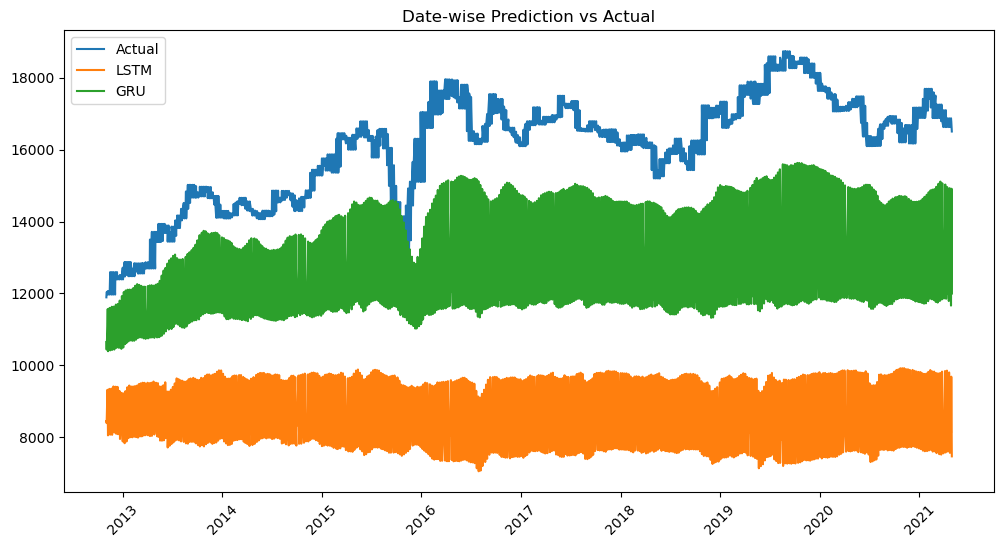

In [85]:
dates = df.index[-len(Y_test_inv):]

plt.figure(figsize=(12,6))
plt.plot(dates, Y_test_inv[:,5], label="Actual")
plt.plot(dates, pred_lstm_inv[:,5], label="LSTM")
plt.plot(dates, pred_gru_inv[:,5], label="GRU")

plt.legend()
plt.xticks(rotation=45)
plt.title("Date-wise Prediction vs Actual")
plt.show()

Loss Curve

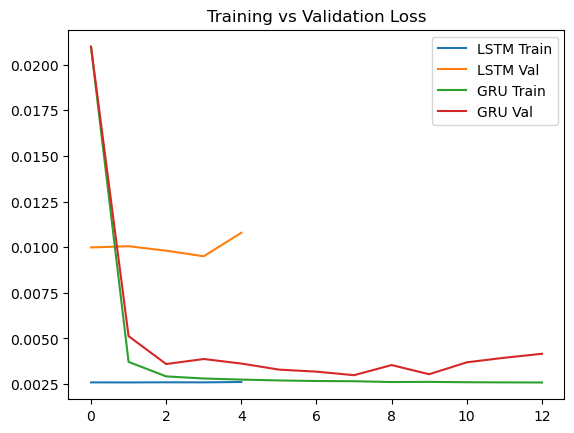

In [86]:
plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val')

plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Val')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Optional Plot (10 -> 5)

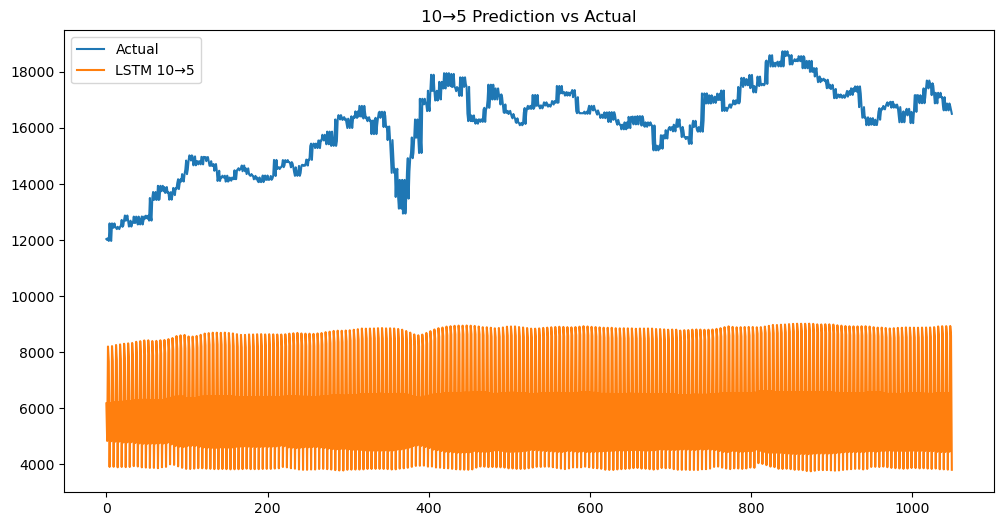

In [87]:
plt.figure(figsize=(12,6))
plt.plot(Y_test_10_inv[:,5], label="Actual")
plt.plot(pred_lstm_10_inv[:,5], label="LSTM 10→5")

plt.legend()
plt.title("10→5 Prediction vs Actual")
plt.show()

Both input configurations (5→5 and 10→5) were implemented using LSTM, and GRU was used for comparison in the 5→5 case.

### Final Observation
Both LSTM and GRU models were implemented for time series prediction using NIFTY stock data.
The GRU model performed slightly better than LSTM based on lower RMSE and MAE values, indicating improved prediction accuracy.